In [ ]:
!unzip "/content/archive (2).zip" -d "/content"


Archive:  /content/archive (2).zip
replace /content/Brain Tumor Segmentation Dataset/image/0/Tr-noTr_0000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import albumentations as A
import numpy as np
from collections import Counter

DATASET_PATH = "/content/Brain Tumor Segmentation Dataset"
CLASSES = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
TARGET_SIZE = (128, 128)

# Augmentation function
def augment_data(image, mask):
    transform = A.Compose([
        A.HorizontalFlip(p=1),
        A.VerticalFlip(p=1),
        A.Rotate(limit=45, p=1),
    ])

    augmented = transform(image=image, mask=mask)
    return augmented["image"], augmented["mask"]



def balance_classes(images, masks, labels, augment_data):

   
    class_counts = Counter(labels)
    max_count = max(class_counts.values())  

    balanced_images = []
    balanced_masks = []
    balanced_labels = []

    for class_index in class_counts.keys():
        class_images = [img for img, lbl in zip(images, labels) if lbl == class_index]
        class_masks = [mask for mask, lbl in zip(masks, labels) if lbl == class_index]

        current_count = len(class_images)


        while current_count < max_count:
            for img, mask in zip(class_images, class_masks):
                aug_img, aug_mask = augment_data(img, mask)  
                balanced_images.append(aug_img)
                balanced_masks.append(aug_mask)
                balanced_labels.append(class_index)
                current_count += 1
                if current_count >= max_count:
                    break

       
        balanced_images.extend(class_images)
        balanced_masks.extend(class_masks)
        balanced_labels.extend([class_index] * len(class_images))

    return (np.array(balanced_images, dtype=np.float32).reshape(-1, 128, 128, 1),
            np.array(balanced_masks, dtype=np.float32).reshape(-1, 128, 128, 1),
            np.array(balanced_labels, dtype=np.int32))


def load_data(data_path, classes, target_size):
    images = []
    masks = []
    labels = []

    for class_index, class_name in enumerate(classes):
        image_folder = os.path.join(data_path, "image", str(class_index))
        mask_folder = os.path.join(data_path, 'mask', str(class_index))

        if not os.path.exists(image_folder) or not os.path.exists(mask_folder):
            continue

        for image_name in tqdm(os.listdir(image_folder), desc=f"Loading {class_name}"):
            if image_name.endswith(('.jpg', '.png')):
                image_path = os.path.join(image_folder, image_name)
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                if image is None:
                    continue

                image = cv2.resize(image, target_size)
                image = image / 255.0

                mask_name = image_name.replace('.jpg', '_m.jpg').replace('.png', '_m.png')
                mask_path = os.path.join(mask_folder, mask_name)

                if os.path.exists(mask_path):
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    if mask is None:
                        continue

                    mask = cv2.resize(mask, target_size)
                    mask = mask / 255.0

                    # Add image and mask
                    images.append(image)
                    masks.append(mask)
                    labels.append(class_index)

                    # Augmented data
                    aug_image, aug_mask = augment_data(image, mask)
                    images.append(aug_image)
                    masks.append(aug_mask)
                    labels.append(class_index)

    # balanced the data :
    images, masks, labels = balance_classes(images, masks, labels, augment_data) # Pass the augment_data function as an argument

    return images, masks, labels

def split_data(images, masks, labels, test_size=0.2):
    Img_train, Img_test, label_train, label_test, mask_train, mask_test = train_test_split(
        images, labels, masks, test_size=test_size, random_state=42, stratify=labels
    )
    return Img_train, Img_test, label_train, label_test, mask_train, mask_test

if __name__ == "__main__":
    images, masks, labels = load_data(DATASET_PATH, CLASSES, TARGET_SIZE)
    print(f"Number of images: {images.shape[0]}, Number of masks: {masks.shape[0]}, Number of labels: {labels.shape[0]}")
    Img_train, Img_test, label_train, label_test, mask_train, mask_test = split_data(images, masks, labels, test_size=0.2)
    print(f"Training data: {Img_train.shape[0]} | Test data: {Img_test.shape[0]}")

Loading pituitary_tumor: 100%|██████████| 994/994 [00:04<00:00, 220.65it/s]


Number of images: 12760, Number of masks: 12760, Number of labels: 12760
Training data: 10208 | Test data: 2552


***Encoding the labels using OneHotEncoder***


In [ ]:
print('labels vector',labels)
# encoding the label using OneHotEncoder :
#train label :
encoder_labels_train=np.array(label_train)
encoder_labels_train=np.eye(4)[encoder_labels_train]
print('the encoded vector of train  : ',encoder_labels_train)
#test label :
encoder_labels_test=np.array(label_test)
encoder_labels_test=np.eye(4)[encoder_labels_test]
print('the encoded vector of test  : ',encoder_labels_test)



labels vector [0 0 0 ... 3 3 3]
the encoded vector of train  :  [[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 ...
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]
the encoded vector of test  :  [[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 ...
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]]


***Implementing CNN***

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten,BatchNormalization, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import LeakyReLU







In [ ]:
batch_size=32
epochs=50
num_classes=4
input_shape=(128,128,1)
optimizer = Adam(learning_rate=0.0001)

***Building the model***

In [ ]:
model=Sequential()

model.add(Input(shape=(128, 128, 1)))  

# 🟢 covelutional 1 :
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# 🟢 covelutional 2 :
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# 🟢 covelutional 3 :
model.add(Conv2D(256, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

# 🟢 covelutional 4 :
model.add(Conv2D(512, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))


#  Flattening:
model.add(Flatten())


# full conected layers:
model.add(Dense(512, kernel_regularizer=l2(0.0005)))
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.3))


model.add(Dense(256, kernel_regularizer=l2(0.0005)))
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.2))

# output layer :
model.add(Dense(num_classes,activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
model.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
              optimizer=optimizer,
              metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)                   │ (None, 126, 126, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_36               │ (None, 126, 126, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_36 (MaxPooling2D)      │ (None, 63, 63, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_41 (Conv2D)                   │ (None, 61, 61, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_37               │ (None, 61, 61, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_37 (MaxPooling2D)      │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_55 (Dropout)                 │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_42 (Conv2D)                   │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_38               │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_38 (MaxPooling2D)      │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_56 (Dropout)                 │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_43 (Conv2D)                   │ (None, 12, 12, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_39               │ (None, 12, 12, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_39 (MaxPooling2D)      │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_57 (Dropout)                 │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_11 (Flatten)                 │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 512)                 │       9,437,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_29 (LeakyReLU)           │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_58 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 11,123,716 (42.43 MB)

 Trainable params: 11,121,796 (42.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

***Training the model ***

In [ ]:

import pickle


history=model.fit(Img_train,encoder_labels_train,batch_size=32,epochs=epochs,verbose=1,validation_data=(Img_test,encoder_labels_test),callbacks=[reduce_lr])

with open('history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

model.save("model1.h5")
print("Model and History Saved 100%")


Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.5819 - loss: 2.3897 - val_accuracy: 0.3064 - val_loss: 5.1996 - learning_rate: 1.0000e-04
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.7228 - loss: 1.7778 - val_accuracy: 0.6611 - val_loss: 2.3246 - learning_rate: 1.0000e-04
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.7599 - loss: 1.6582 - val_accuracy: 0.7700 - val_loss: 1.8061 - learning_rate: 1.0000e-04
Epoch 4/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.7908 - loss: 1.5730 - val_accuracy: 0.7837 - val_loss: 1.7808 - learning_rate: 1.0000e-04
Epoch 5/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.8176 - loss: 1.4920 - val_accuracy: 0.7531 - val_loss: 2.0836 - learning_rate: 1.0000e-04
Epoch 6/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.8472 - loss: 1.3983 - val_accuracy: 0.8401 - val_loss: 1.5448 - learning_rate: 1.0000e-04
Epoch 7/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/ste

Model and History Saved 100%


In [ ]:
test_loss, test_accuracy = model.evaluate(Img_test, encoder_labels_test, batch_size=30)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9762 - loss: 0.4679
Test Accuracy: 0.9718
Test Loss: 0.4801


In [ ]:
from sklearn.metrics import classification_report
import numpy as np


y_pred_prob = model.predict(Img_test, batch_size=16)


y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(encoder_labels_test, axis=1) 


report = classification_report(y_true, y_pred)

print(report)


160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       638
           1       0.97      0.99      0.98       638
           2       0.98      0.92      0.95       638
           3       0.96      0.99      0.98       638

    accuracy                           0.97      2552
   macro avg       0.97      0.97      0.97      2552
weighted avg       0.97      0.97      0.97      2552



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


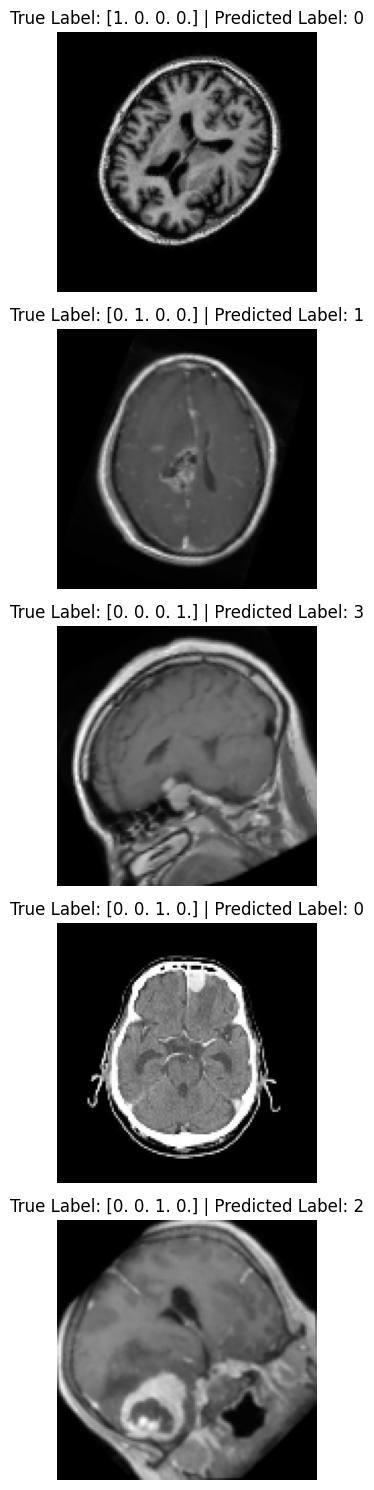

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def test_model(model, image_test, encoder_label_test, num_samples=5):
    indices = np.random.choice(len(Img_test), num_samples, replace=False)
    plt.figure(figsize=(15, num_samples * 3))

    for i, idx in enumerate(indices):
        test_image = Img_test[idx]
        true_label = encoder_label_test[idx]  # True class label

        test_image_input = np.expand_dims(test_image, axis=0)
        pred_label = model.predict(test_image_input).argmax(axis=1)[0]  # Predicted class label

        plt.subplot(num_samples, 1, i + 1)
        plt.imshow(test_image, cmap='gray')
        plt.title(f"True Label: {true_label} | Predicted Label: {pred_label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

test_model(model, Img_test, encoder_labels_test, num_samples=5)


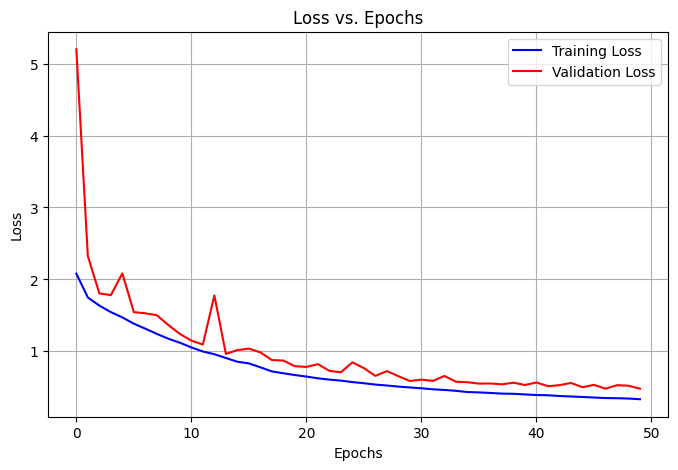

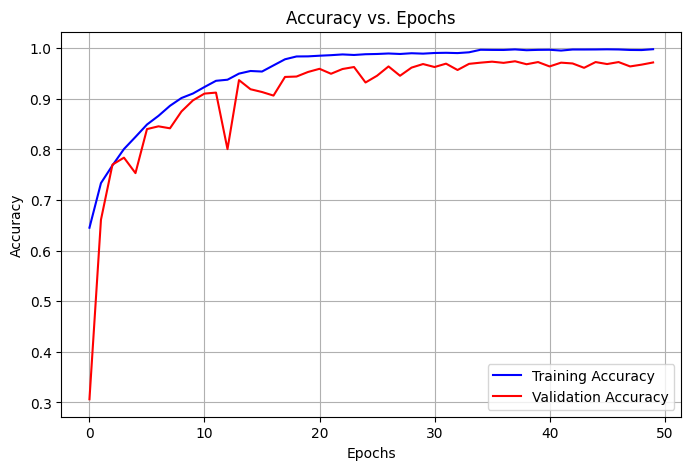

In [ ]:
import matplotlib.pyplot as plt


train_loss = history.history['loss']
val_loss = history.history['val_loss']


plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')


plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs')
plt.legend()
plt.grid()
plt.show()




train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epochs')
plt.legend()
plt.grid()
plt.show()

!pip uninstall -y keras keras-nightly keras-preprocessing keras-applications
!pip uninstall -y tensorflow
!pip install --upgrade tensorflow

1.   List item
2.   List item

